# Cálculo de Z-Score y Detección de Outliers

El **Z-Score** (o puntaje estándar) es una medida estadística que nos dice a cuántas desviaciones estándar se encuentra un punto de datos respecto a la media de la distribución. Es fundamental para identificar valores atípicos (outliers) en distribuciones que se aproximan a una normal.

## 1. Definición Matemática

La fórmula para calcular el Z-score de un valor $x$ es:

$$Z = \frac{x - \mu}{\sigma}$$

Donde:
- $x$: es el valor observado.
- $\mu$: es la media de la muestra.
- $\sigma$: es la desviación estándar de la muestra.

### Regla de Oro para Outliers:
- Un **Z-score > 3** o **< -3** se considera generalmente como un outlier (valor muy alejado de lo común).

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos el dataset 'bupa' que usamos en clase
try:
    data = pd.read_csv("bupa.csv", sep=';')
except:
    # URL por si no está localmente
    url = "https://raw.githubusercontent.com/dReposU/ML/main/Sem_2/bupa.csv"
    data = pd.read_csv(url, sep=';')

print("Primeras filas del dataset:")
data.head()

Primeras filas del dataset:


,V1,V2,V3,V4,V5,V6,V7
0,85,92,45,27,31,0.0,1
1,85,64,59,32,23,0.0,2
2,86,54,33,16,54,0.0,2
3,91,78,34,24,36,0.0,2
4,87,70,12,28,10,0.0,2


## 2. Cálculo Manual del Z-Score

Vamos a calcularlo paso a paso para la columna `V1`.

In [2]:
mean_v1 = data['V1'].mean()
std_v1 = data['V1'].std()

print(f"Media de V1: {mean_v1}")
print(f"Desviación Estándar de V1: {std_v1}")

# Aplicamos la fórmula: (x - media) / desviación
data['Z_Score_V1'] = (data['V1'] - mean_v1) / std_v1

data[['V1', 'Z_Score_V1']].head()

Media de V1: 90.15942028985508
Desviación Estándar de V1: 4.448095974964356


,V1,Z_Score_V1
0,85,-1.159917
1,85,-1.159917
2,86,-0.935101
3,91,0.188975
4,87,-0.710286


## 3. Cálculo con Scipy (Forma rápida)

La librería `scipy.stats` tiene una función optimizada para esto.

In [3]:
data['Z_Score_Scipy'] = stats.zscore(data['V1'])
data[['V1', 'Z_Score_V1', 'Z_Score_Scipy']].head()

,V1,Z_Score_V1,Z_Score_Scipy
0,85,-1.159917,-1.161601
1,85,-1.159917,-1.161601
2,86,-0.935101,-0.936459
3,91,0.188975,0.189250
4,87,-0.710286,-0.711318


## 4. Identificación de Outliers

Filtramos los datos donde el valor absoluto del Z-score sea mayor a 3.

In [4]:
outliers = data[np.abs(data['Z_Score_V1']) > 3]

print(f"Número de outliers detectados: {len(outliers)}")
outliers

Número de outliers detectados: 1


,V1,V2,V3,V4,V5,V6,V7,Z_Score_V1,Z_Score_Scipy
223,65,63,19,20,14,0.5,2,-5.656222,-5.664438


## 5. Visualización

Una gráfica de distribución nos ayuda a visualizar qué tan lejos están estos puntos.

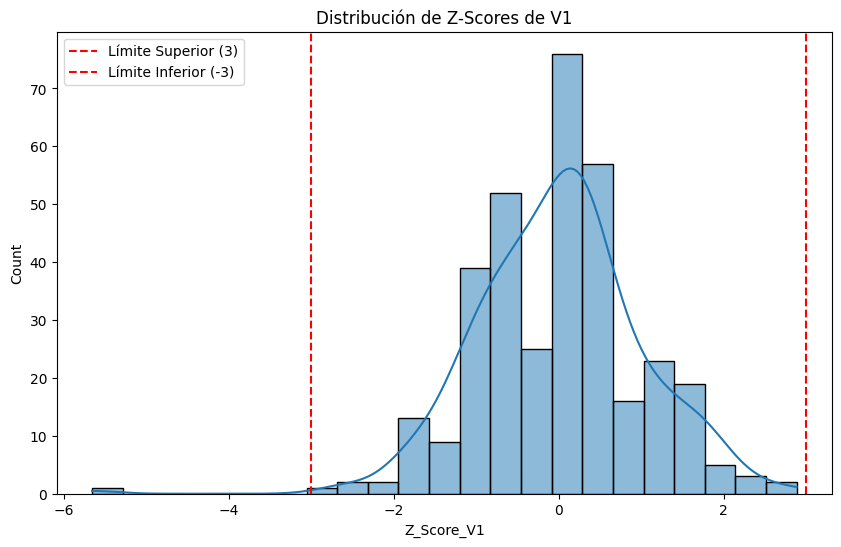

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(data['Z_Score_V1'], kde=True)
plt.axvline(3, color='red', linestyle='--', label='Límite Superior (3)')
plt.axvline(-3, color='red', linestyle='--', label='Límite Inferior (-3)')
plt.title('Distribución de Z-Scores de V1')
plt.legend()
plt.show()

### Conclusión para el Examen:
- El **Z-score** estandariza los datos (media 0, varianza 1).
- Es sensible a la media, por lo que si hay outliers extremos, la media se desplaza y el Z-score puede no ser tan efectivo como el **IQR** (Rango Intercuartílico).
- Solo debe usarse si la distribución es aproximadamente **Normal**.